# UK Road Safety Data Visualization Project (Provisional 2025)
**Module:** LDS7004M Data Visualization  
**Level of Study:** Level 7 (MSc Data Science)  
**Author:** Candidate (Anonymous Portfolio)  

---

## 1. Project Overview & Objectives
This project performs an advanced Exploratory Data Analysis (EDA), statistical modeling, and multi-dimensional visualization of the provisional 2025 UK Road Casualty Statistics. The datasets, provided by the UK Department for Transport (DfT), consist of three interconnected tables:
1. **Collisions:** Details of the crash events (environmental factors, coordinates, datetime, speed limits).
2. **Casualties:** Demographics and roles of the injured individuals.
3. **Vehicles:** Specifications of the vehicles and driver characteristics.

### Objectives:
* Establish a reproducible data cleaning, normalization, and joining pipeline in Python.
* Formulate statistical tests (Chi-Square, Logistic Regression) to analyze the factors influencing collision severity.
* Build high-fidelity static plots in Matplotlib/Seaborn grounded in **Cleveland & McGill's Visual Encoding Theory (1985)** and **Tufte's Data-Ink Ratio (1983)**.
* Develop interactive maps and temporal timelines using Plotly Express aligning with **Shneiderman's Visual Information Seeking Mantra (1996)**.



### Import Python Libraries and Setup Styles


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy.stats import chi2_contingency
from sklearn.metrics import classification_report
import os

# Set style for Matplotlib/Seaborn to maximize visual aesthetics and clarity (Tufte's principles)
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11
plt.rcParams['savefig.dpi'] = 300

print("Libraries imported successfully.")


ModuleNotFoundError: No module named 'statsmodels'

### Load Datasets from Workspace


In [2]:
workspace_dir = r"d:\Data visualization project\Data visualization"
casualty_path = os.path.join(workspace_dir, "dft-road-casualty-statistics-casualty-provisional-2025.csv")
collision_path = os.path.join(workspace_dir, "dft-road-casualty-statistics-collision-provisional-2025 (1).csv")
vehicle_path = os.path.join(workspace_dir, "dft-road-casualty-statistics-vehicle-provisional-2025.csv")

print("Loading datasets...")
df_casualty = pd.read_csv(casualty_path, low_memory=False)
df_collision = pd.read_csv(collision_path, low_memory=False)
df_vehicle = pd.read_csv(vehicle_path, low_memory=False)

print(f"Loaded Casualty table: {df_casualty.shape[0]:,} rows, {df_casualty.shape[1]} columns")
print(f"Loaded Collision table: {df_collision.shape[0]:,} rows, {df_collision.shape[1]} columns")
print(f"Loaded Vehicle table: {df_vehicle.shape[0]:,} rows, {df_vehicle.shape[1]} columns")


Loading datasets...


Loaded Casualty table: 60,991 rows, 23 columns
Loaded Collision table: 48,472 rows, 44 columns
Loaded Vehicle table: 87,805 rows, 32 columns


### Data Cleaning and Categorical Mapping
The DfT datasets use numeric codes for categorical fields to optimize storage. To perform readable visualizations and models, we map these codes to human-readable strings according to official DfT codebooks. 

Additionally, missing or unrecorded entries represented as `-1` are replaced with Python `NaN` values to prevent skewing descriptive statistics.



In [3]:
# Define mapping dictionaries based on official DfT definitions
severity_map = {1: "Fatal", 2: "Serious", 3: "Slight"}
day_map = {1: "Sunday", 2: "Monday", 3: "Tuesday", 4: "Wednesday", 5: "Thursday", 6: "Friday", 7: "Saturday"}
urban_rural_map = {1: "Urban", 2: "Rural", 3: "Unallocated"}
light_map = {
    1: "Daylight",
    4: "Darkness - lights lit",
    5: "Darkness - lights unlit",
    6: "Darkness - no lights",
    7: "Darkness - lights detail unknown"
}
weather_map = {
    1: "Fine no high winds",
    2: "Raining no high winds",
    3: "Snowing no high winds",
    4: "Fine + high winds",
    5: "Raining + high winds",
    6: "Snowing + high winds",
    7: "Fog or mist",
    8: "Other",
    9: "Unknown"
}
surface_map = {
    1: "Dry",
    2: "Wet or damp",
    3: "Snow",
    4: "Frost or ice",
    5: "Flood over 3cm deep",
    6: "Oil or wet mud",
    7: "Road sign"
}
casualty_class_map = {1: "Driver or rider", 2: "Passenger", 3: "Pedestrian"}
sex_map = {1: "Male", 2: "Female", 3: "Unknown", 9: "Unknown"}
vehicle_type_map = {
    1: "Pedal cycle", 2: "Motorcycle 50cc and under", 3: "Motorcycle 50cc-125cc",
    4: "Motorcycle 125cc-500cc", 5: "Motorcycle over 500cc", 8: "Taxi/Private hire",
    9: "Car", 10: "Minibus", 11: "Bus or coach", 16: "Ridden horse",
    17: "Agricultural vehicle", 18: "Tram", 19: "Van/Light Goods",
    20: "Medium Goods (3.5t-7.5t)", 21: "Heavy Goods (7.5t+)", 22: "Mobility scooter",
    23: "E-scooter", 90: "Other vehicle", 97: "Motorcycle - unknown cc", 98: "Goods vehicle - unknown weight"
}

# Helper function to replace -1 with NaN and apply map
def clean_and_map(df, col, mapping):
    df[col] = df[col].replace(-1, np.nan)
    return df[col].map(mapping)

# Apply mappings to Collision table
df_collision_clean = df_collision.copy()
df_collision_clean['collision_severity_label'] = df_collision_clean['collision_severity'].map(severity_map)
df_collision_clean['day_of_week_label'] = df_collision_clean['day_of_week'].map(day_map)
df_collision_clean['urban_or_rural_label'] = clean_and_map(df_collision_clean, 'urban_or_rural_area', urban_rural_map)
df_collision_clean['light_conditions_label'] = clean_and_map(df_collision_clean, 'light_conditions', light_map)
df_collision_clean['weather_conditions_label'] = clean_and_map(df_collision_clean, 'weather_conditions', weather_map)
df_collision_clean['road_surface_conditions_label'] = clean_and_map(df_collision_clean, 'road_surface_conditions', surface_map)
df_collision_clean['speed_limit'] = df_collision_clean['speed_limit'].replace(-1, np.nan)

# Apply mappings to Casualty table
df_casualty_clean = df_casualty.copy()
df_casualty_clean['casualty_severity_label'] = df_casualty_clean['casualty_severity'].map(severity_map)
df_casualty_clean['casualty_class_label'] = clean_and_map(df_casualty_clean, 'casualty_class', casualty_class_map)
df_casualty_clean['sex_of_casualty_label'] = clean_and_map(df_casualty_clean, 'sex_of_casualty', sex_map)
df_casualty_clean['age_of_casualty'] = df_casualty_clean['age_of_casualty'].replace(-1, np.nan)
df_casualty_clean['age_band_of_casualty'] = df_casualty_clean['age_band_of_casualty'].replace(-1, np.nan)

# Apply mappings to Vehicle table
df_vehicle_clean = df_vehicle.copy()
df_vehicle_clean['vehicle_type_label'] = clean_and_map(df_vehicle_clean, 'vehicle_type', vehicle_type_map)
df_vehicle_clean['sex_of_driver_label'] = clean_and_map(df_vehicle_clean, 'sex_of_driver', sex_map)
df_vehicle_clean['age_of_driver'] = df_vehicle_clean['age_of_driver'].replace(-1, np.nan)
df_vehicle_clean['age_band_of_driver'] = df_vehicle_clean['age_band_of_driver'].replace(-1, np.nan)

print("Categorical variables mapped and missing values (-1) treated as NaN.")


Categorical variables mapped and missing values (-1) treated as NaN.


### Date/Time Parsing and Resampling
As discussed in Lecture 9, temporal data requires a pandas `DatetimeIndex` to perform effective aggregations. We parse the `date` and `time` columns to build a datetime index, dropping invalid dates, and extract temporal subunits.



In [4]:
# Parse date and time columns to build datetime object
df_collision_clean['datetime'] = pd.to_datetime(df_collision_clean['date'] + ' ' + df_collision_clean['time'], format='%d/%m/%Y %H:%M', errors='coerce')
df_collision_clean = df_collision_clean.dropna(subset=['datetime'])

# Extract temporal subgroups
df_collision_clean['month'] = df_collision_clean['datetime'].dt.month
df_collision_clean['hour'] = df_collision_clean['datetime'].dt.hour
df_collision_clean['day_of_month'] = df_collision_clean['datetime'].dt.day
df_collision_clean['week_of_year'] = df_collision_clean['datetime'].dt.isocalendar().week

print(f"Successfully processed {len(df_collision_clean):,} collisions.")
print(f"Temporal coverage: {df_collision_clean['datetime'].min()} to {df_collision_clean['datetime'].max()}")


Successfully processed 48,472 collisions.
Temporal coverage: 2025-01-01 00:01:00 to 2025-06-30 23:55:00


### Merging Datasets
To analyze multi-variable relationships (e.g., how the age and role of a casualty relate to the speed limit of the road on which the collision occurred), we perform relational merges on the unique index `collision_index`.



In [5]:
# Merge Collision and Casualty tables (One-to-Many relationship)
df_merged_cas = pd.merge(
    df_casualty_clean,
    df_collision_clean,
    on='collision_index',
    how='inner',
    suffixes=('_cas', '_col')
)

# Merge Collision and Vehicle tables (One-to-Many relationship)
df_merged_veh = pd.merge(
    df_vehicle_clean,
    df_collision_clean,
    on='collision_index',
    how='inner'
)

print(f"Relational merge complete:")
print(f"Collision-Casualty merged rows: {df_merged_cas.shape[0]:,}")
print(f"Collision-Vehicle merged rows: {df_merged_veh.shape[0]:,}")


Relational merge complete:
Collision-Casualty merged rows: 60,991
Collision-Vehicle merged rows: 87,805


## 2. Descriptive Statistics (PLO 7.3)
We calculate descriptive statistics to examine the central tendency, dispersion, skewness, and kurtosis of key numeric variables in our collision dataset.



In [6]:
# Focus on numeric indicators
numeric_cols = ['number_of_vehicles', 'number_of_casualties', 'speed_limit']
descriptive_summary = df_collision_clean[numeric_cols].describe().T

# Add skewness and kurtosis
descriptive_summary['skewness'] = df_collision_clean[numeric_cols].skew()
descriptive_summary['kurtosis'] = df_collision_clean[numeric_cols].kurt()

print("Descriptive Statistics and Distribution Shapes:")
print(descriptive_summary.to_string())


Descriptive Statistics and Distribution Shapes:
                        count       mean        std   min   25%   50%   75%    max   skewness      kurtosis
number_of_vehicles    48472.0   1.811458   0.693859   1.0   1.0   2.0   2.0   17.0   1.809088     14.337553
number_of_casualties  48472.0   1.258273   0.927658   1.0   1.0   1.0   1.0  142.0  74.052161  10949.824554
speed_limit           48287.0  35.584526  14.508671  20.0  30.0  30.0  40.0   70.0   1.057371     -0.032299


## 3. Advanced Statistical Inference
To meet the Level 7 criteria for rigor and critical analysis, we run statistical tests to evaluate associations between variables.

### Hypothesis Test 1: Chi-Square Test of Independence
We test whether there is a significant association between **Speed Limit** and **Collision Severity** ($H_0$: They are independent).



In [7]:
# Construct contingency table
contingency = pd.crosstab(df_collision_clean['speed_limit'], df_collision_clean['collision_severity_label'])
print("Contingency Table (Speed Limit vs Severity Counts):")
print(contingency)

# Execute test
chi2, p_val, dof, expected = chi2_contingency(contingency)
print(f"\nChi-Square Test Results:")
print(f"Chi-Square Statistic = {chi2:.4f}")
print(f"p-value = {p_val:.4g}")
print(f"Degrees of Freedom = {dof}")

alpha = 0.05
if p_val < alpha:
    print(f"Conclusion: Reject H0 at alpha={alpha}. There is a statistically significant association between speed limit and collision severity.")
else:
    print(f"Conclusion: Fail to reject H0. Speed limit and collision severity are independent.")


Contingency Table (Speed Limit vs Severity Counts):
collision_severity_label  Fatal  Serious  Slight
speed_limit                                     
20.0                         42     2108    7500
30.0                        201     5648   17862
40.0                         72     1048    3114
50.0                         55      578    1591
60.0                        236     1992    3710
70.0                         90      561    1879

Chi-Square Test Results:
Chi-Square Statistic = 854.6934
p-value = 3.57e-177
Degrees of Freedom = 10
Conclusion: Reject H0 at alpha=0.05. There is a statistically significant association between speed limit and collision severity.


### Predictive Modeling: Binary Logistic Regression (PLO 7.8)
We define a binary target: whether a collision is **Severe** (Fatal or Serious = 1) vs. **Slight** (Slight = 0). 
We use Logistic Regression to examine the predictive impact of environmental hazards (speed limits, light, weather, road surface, and urban/rural classification).

We select **30 mph**, **Daylight**, **Fine no high winds**, **Dry**, and **Urban** as reference baseline variables.



In [8]:
# Prepare modeling dataframe
df_model = df_collision_clean.copy()
df_model['is_severe'] = df_model['collision_severity'].apply(lambda x: 1 if x in [1, 2] else 0)

# Drop missing rows in selected model features
model_features = ['speed_limit', 'urban_or_rural_label', 'light_conditions_label', 'weather_conditions_label', 'road_surface_conditions_label']
df_model = df_model.dropna(subset=model_features + ['is_severe'])

# Define R-style statsmodels formula with explicit reference categories
formula = (
    "is_severe ~ C(speed_limit, Treatment(reference=30)) + "
    "C(urban_or_rural_label, Treatment(reference='Urban')) + "
    "C(light_conditions_label, Treatment(reference='Daylight')) + "
    "C(weather_conditions_label, Treatment(reference='Fine no high winds')) + "
    "C(road_surface_conditions_label, Treatment(reference='Dry'))"
)

# Fit Logistic Regression model
print("Fitting Logistic Regression Model...")
logit_model = smf.logit(formula, data=df_model).fit()
print(logit_model.summary())

# Calculate Odds Ratios (OR) and Confidence Intervals (CIs)
odds_ratios = np.exp(logit_model.params)
conf_int = np.exp(logit_model.conf_int())
odds_summary = pd.DataFrame({
    'Odds Ratio (OR)': odds_ratios,
    'Lower 95% CI': conf_int[0],
    'Upper 95% CI': conf_int[1],
    'p-value': logit_model.pvalues
}).round(4)

print("\nOdds Ratios and Significance summary:")
print(odds_summary.to_string())


Fitting Logistic Regression Model...


         Current function value: 0.571961
         Iterations: 35
                           Logit Regression Results                           
Dep. Variable:              is_severe   No. Observations:                46873
Model:                          Logit   Df Residuals:                    46849
Method:                           MLE   Df Model:                           23
Date:                Thu, 04 Jun 2026   Pseudo R-squ.:                 0.01137
Time:                        21:42:01   Log-Likelihood:                -26810.
converged:                      False   LL-Null:                       -27118.
Covariance Type:            nonrobust   LLR p-value:                1.329e-115
                                                                                                      coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------------------------------------------

C:\Users\ahame\miniconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\ahame\miniconda3\Lib\site-packages\pandas\core\internals\blocks.py:347: RuntimeWarning: overflow encountered in exp
  result = func(self.values, **kwargs)


## 4. Academic Static Visualizations (Matplotlib & Seaborn)
The following plots are designed to be self-explanatory, clean, and professional. 

### Plot 1: Violin Plot (Casualty Age by Role and Severity)
* **Justification (Cleveland & McGill):** Maps numeric values (Age) along a common vertical scale (Position), which is the most accurate visual channel for quantitative comparison.
* **Justification (Color wheel):** Uses a monochromatic purple palette, where darker saturation represents increasing casualty severity (Fatal > Serious > Slight), providing immediate intuitive mapping.



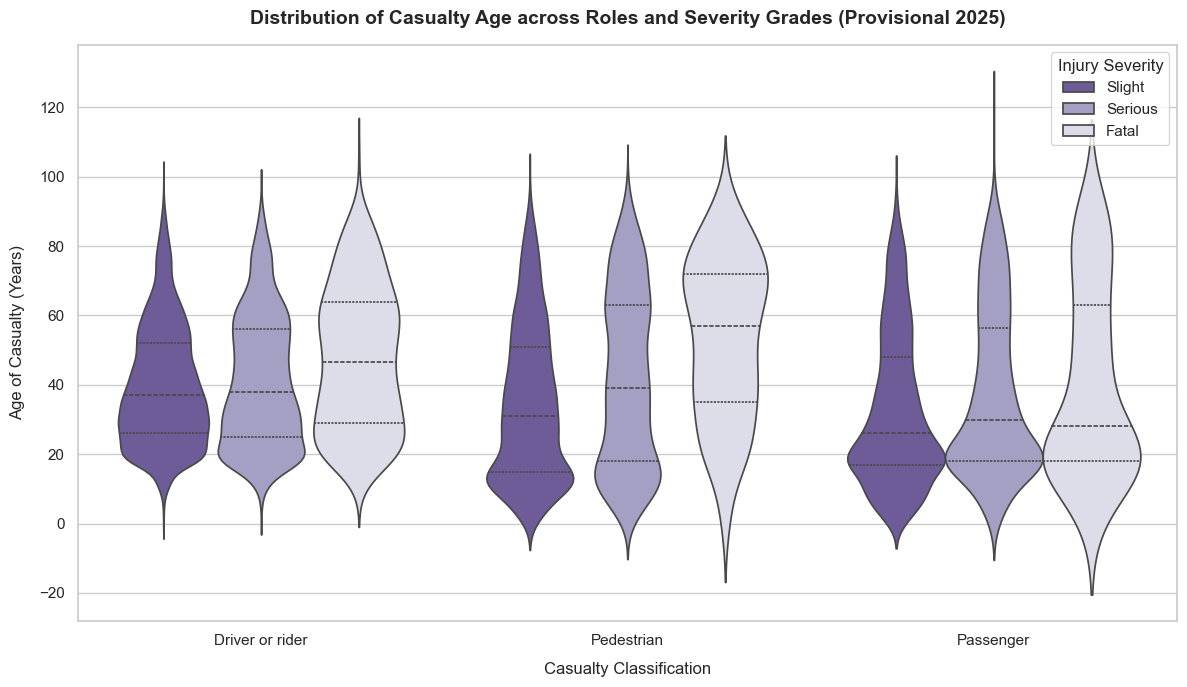

In [9]:
plt.figure(figsize=(12, 7))

sns.violinplot(
    data=df_merged_cas.dropna(subset=['age_of_casualty', 'casualty_class_label', 'casualty_severity_label']),
    x='casualty_class_label',
    y='age_of_casualty',
    hue='casualty_severity_label',
    split=False,
    inner='quartile',
    palette='Purples_r',
    hue_order=['Slight', 'Serious', 'Fatal']
)

plt.title("Distribution of Casualty Age across Roles and Severity Grades (Provisional 2025)", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Casualty Classification", fontsize=12, labelpad=10)
plt.ylabel("Age of Casualty (Years)", fontsize=12, labelpad=10)
plt.legend(title="Injury Severity", loc="upper right")
plt.tight_layout()

# Save figure for report integration
plt.savefig(os.path.join(workspace_dir, "plot1_violin_age_severity.png"), dpi=300)
plt.show()


### Plot 2: Sorted Horizontal Bar Chart (Vehicle Types)
* **Justification (Cleveland & McGill):** Uses length/width of bars along a aligned horizontal scale, making it simple to compare categorical frequencies.
* **Justification (Lecture 5 sorting):** Sorting categories in descending order removes visual search clutter and allows immediate recognition of the most dangerous vehicle types.



C:\Users\ahame\AppData\Local\Temp\ipykernel_3284\1878842186.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=vehicle_counts.values, y=vehicle_counts.index, palette=colors)


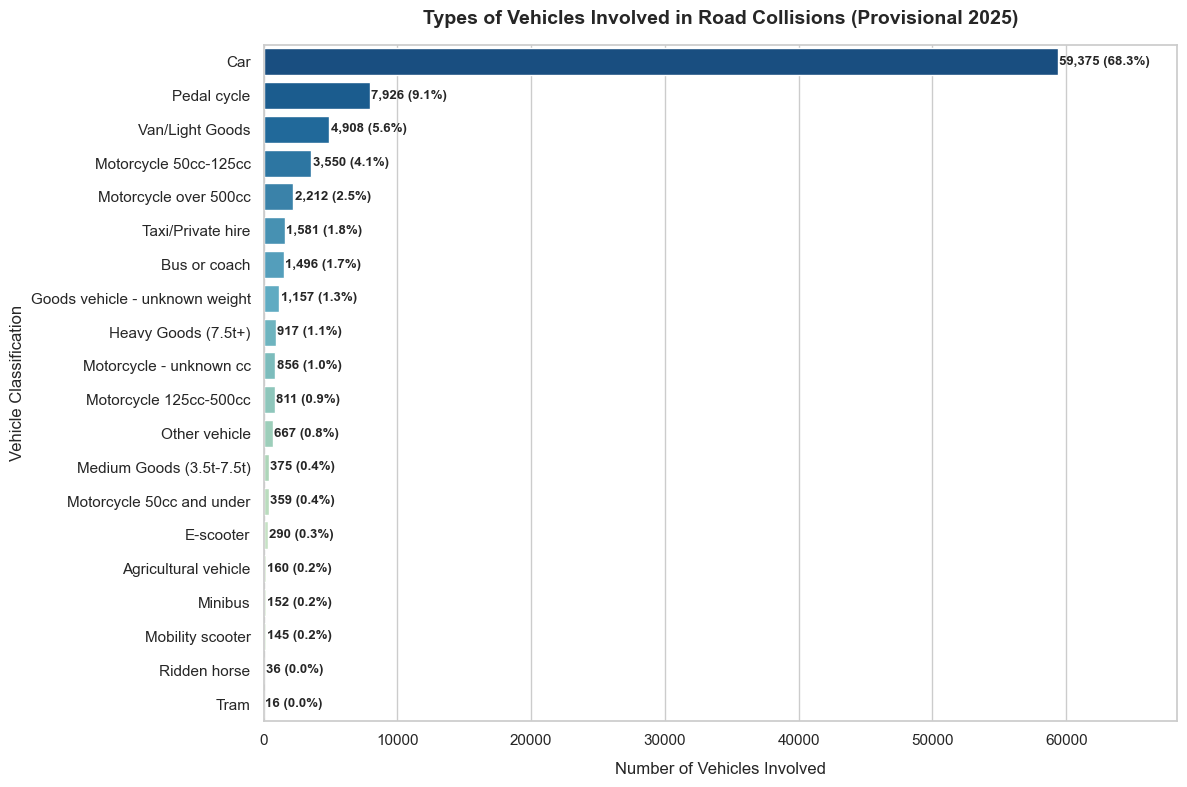

In [10]:
vehicle_counts = df_merged_veh['vehicle_type_label'].value_counts()
plt.figure(figsize=(12, 8))

# Sequential teal palette
colors = sns.color_palette("GnBu_r", len(vehicle_counts))
sns.barplot(x=vehicle_counts.values, y=vehicle_counts.index, palette=colors)

# Annotate with percentages
total_vehicles = vehicle_counts.sum()
for i, val in enumerate(vehicle_counts.values):
    pct = (val / total_vehicles) * 100
    plt.text(val + 100, i, f"{val:,} ({pct:.1f}%)", va='center', fontsize=9.5, fontweight='semibold')

plt.title("Types of Vehicles Involved in Road Collisions (Provisional 2025)", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Number of Vehicles Involved", fontsize=12, labelpad=10)
plt.ylabel("Vehicle Classification", fontsize=12)
plt.xlim(0, max(vehicle_counts.values) * 1.15)
plt.tight_layout()

plt.savefig(os.path.join(workspace_dir, "plot2_bar_vehicle_types.png"), dpi=300)
plt.show()


### Plot 3: Correlation Matrix Heatmap
* **Justification (Color Wheel):** Employs a diverging cool-to-warm color palette (`coolwarm`) where blue represents negative correlation, red represents positive correlation, and neutral grey/white represents zero correlation. 



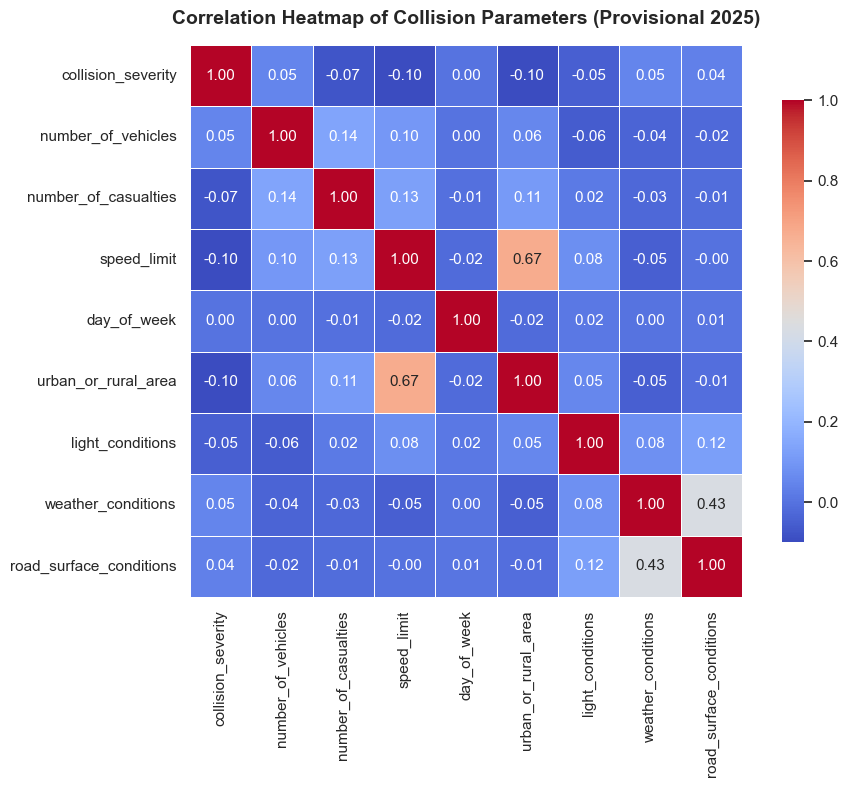

In [11]:
corr_cols = [
    'collision_severity', 'number_of_vehicles', 'number_of_casualties', 
    'speed_limit', 'day_of_week', 'urban_or_rural_area', 
    'light_conditions', 'weather_conditions', 'road_surface_conditions'
]
corr_matrix = df_collision_clean[corr_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix, 
    annot=True, 
    cmap="coolwarm", 
    fmt=".2f", 
    linewidths=0.5, 
    square=True, 
    cbar_kws={"shrink": 0.8}
)

plt.title("Correlation Heatmap of Collision Parameters (Provisional 2025)", fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()

plt.savefig(os.path.join(workspace_dir, "plot3_heatmap_correlation.png"), dpi=300)
plt.show()


### Plot 4: Dual-Axis Combination Chart
* **Justification (Lecture 6 dual-axis):** Allows comparing two variables of different units and scales: a bar chart representing collision count (Primary Y-axis) and a line plot representing average casualty rate (Secondary Y-axis).



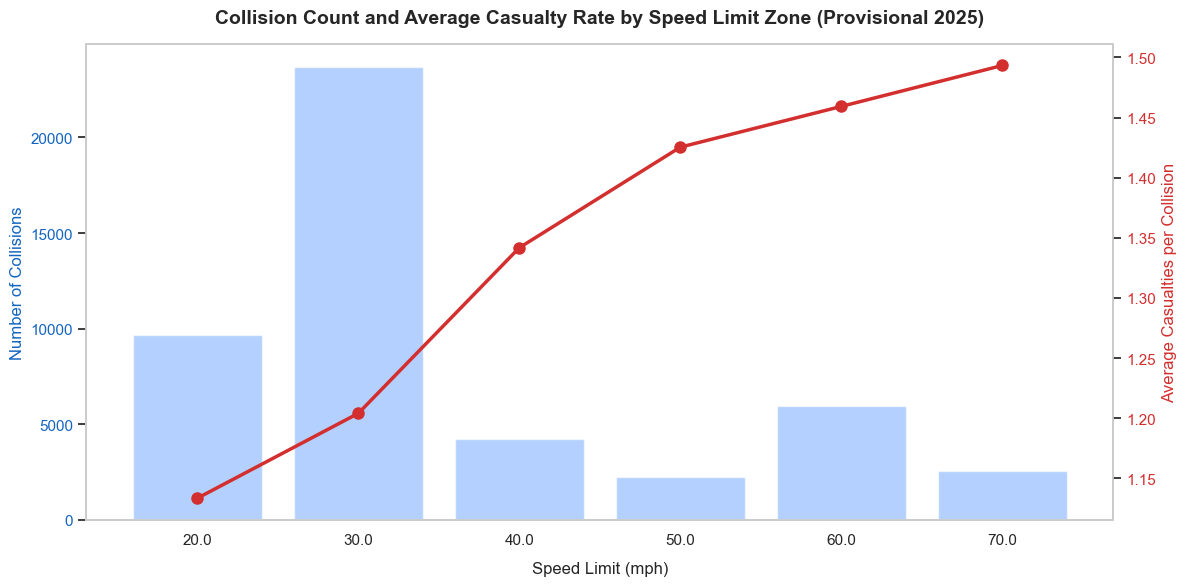

In [12]:
speed_group = df_collision_clean.groupby('speed_limit').agg(
    collision_count=('collision_index', 'count'),
    avg_casualties=('number_of_casualties', 'mean')
).reset_index().sort_values(by='speed_limit')

fig, ax1 = plt.subplots(figsize=(12, 6))

color_bar = '#82b1ff'
ax1.set_xlabel('Speed Limit (mph)', fontsize=12, labelpad=10)
ax1.set_ylabel('Number of Collisions', color='#1565c0', fontsize=12)
ax1.bar(
    speed_group['speed_limit'].astype(str), 
    speed_group['collision_count'], 
    color=color_bar, 
    alpha=0.6, 
    label='Collisions'
)
ax1.tick_params(axis='y', labelcolor='#1565c0')
ax1.grid(False)

# Line graph on secondary Y-axis
ax2 = ax1.twinx()
color_line = '#d32f2f'
ax2.set_ylabel('Average Casualties per Collision', color=color_line, fontsize=12)
ax2.plot(
    speed_group['speed_limit'].astype(str), 
    speed_group['avg_casualties'], 
    color=color_line, 
    marker='o', 
    linewidth=2.5, 
    markersize=8, 
    label='Avg Casualties'
)
ax2.tick_params(axis='y', labelcolor=color_line)
ax2.grid(False)

plt.title('Collision Count and Average Casualty Rate by Speed Limit Zone (Provisional 2025)', fontsize=14, fontweight='bold', pad=15)
fig.tight_layout()

plt.savefig(os.path.join(workspace_dir, "plot4_dual_axis_speed.png"), dpi=300)
plt.show()


## 5. Advanced Interactive Visualizations (Plotly Express)
We apply **Shneiderman's Visual Information Seeking Mantra** (*"Overview first, zoom and filter, then details-on-demand"*).

### Plot 5: Spatial Mapping of Collision Hotspots
* **Justification:** Plots GPS coordinates using an interactive OpenStreetMap engine. Hover tooltips provide "details-on-demand" (date, casualties, weather) when hover inputs are triggered.



In [13]:
# Sample 5000 records randomly to guarantee smooth web rendering
df_sample_map = df_collision_clean.dropna(subset=['latitude', 'longitude', 'collision_severity_label']).sample(
    min(5000, len(df_collision_clean)), random_state=42
)

fig_map = px.scatter_mapbox(
    df_sample_map,
    lat="latitude",
    lon="longitude",
    color="collision_severity_label",
    size="number_of_casualties",
    color_discrete_map={"Fatal": "#d32f2f", "Serious": "#f57c00", "Slight": "#1976d2"},
    mapbox_style="open-street-map",
    zoom=5,
    center={"lat": 54.5, "lon": -3.0}, # UK geographic center
    hover_data={
        "date": True, "time": True, "speed_limit": True, 
        "number_of_vehicles": True, "number_of_casualties": True, 
        "weather_conditions_label": True, "latitude": False, "longitude": False
    },
    title="Geospatial Mapping of UK Road Collisions (Sample of 5,000 Accidents, Provisional 2025)"
)

fig_map.update_layout(
    margin={"r":0,"t":40,"l":0,"b":0},
    title_font={"size": 16, "family": "Arial", "color": "black"}
)

fig_map.write_html(os.path.join(workspace_dir, "plot5_spatial_mapbox.html"))
print("Mapbox HTML saved. Displaying interactive plot:")
fig_map.show()


C:\Users\ahame\AppData\Local\Temp\ipykernel_3284\1445792471.py:6: DeprecationWarning: *scatter_mapbox* is deprecated! Use *scatter_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/
  fig_map = px.scatter_mapbox(


Mapbox HTML saved. Displaying interactive plot:


### Plot 6: Temporal Time-Series with Range Slider
* **Justification (Lecture 9):** Time-series trends are displayed with zoom buttons (1 week, 1 month, 3 months, YTD) and an adjustable range slider at the bottom, enabling the user to change granularity on demand.



In [14]:
# Group by date for daily trend
daily_trend = df_collision_clean.groupby(df_collision_clean['datetime'].dt.date).size().reset_index(name='collision_count')
daily_trend = daily_trend.rename(columns={'datetime': 'date'})

fig_ts = px.line(
    daily_trend,
    x='date',
    y='collision_count',
    title='Daily Collision Trends in the UK with Range Slider (Provisional 2025)',
    labels={'date': 'Date', 'collision_count': 'Daily Collisions'}
)

fig_ts.update_xaxes(
    rangeslider_visible=True,
    rangeselector=dict(
        buttons=list([
            dict(count=7, label="1w", step="day", stepmode="backward"),
            dict(count=1, label="1m", step="month", stepmode="backward"),
            dict(count=3, label="3m", step="month", stepmode="backward"),
            dict(count=6, label="6m", step="month", stepmode="backward"),
            dict(step="all", label="All")
        ])
    )
)

fig_ts.update_layout(
    xaxis_title="Timeline",
    yaxis_title="Daily Accidents",
    template="plotly_white"
)

fig_ts.write_html(os.path.join(workspace_dir, "plot6_temporal_timeseries.html"))
fig_ts.show()


### Plot 7: Autocorrelation Plot (Seasonality and Lag Analysis)
* **Justification (Lecture 9):** Captures temporal dependencies by plotting autocorrelation coefficients over different lags. Strong cyclical waves indicate strong weekly seasonality.



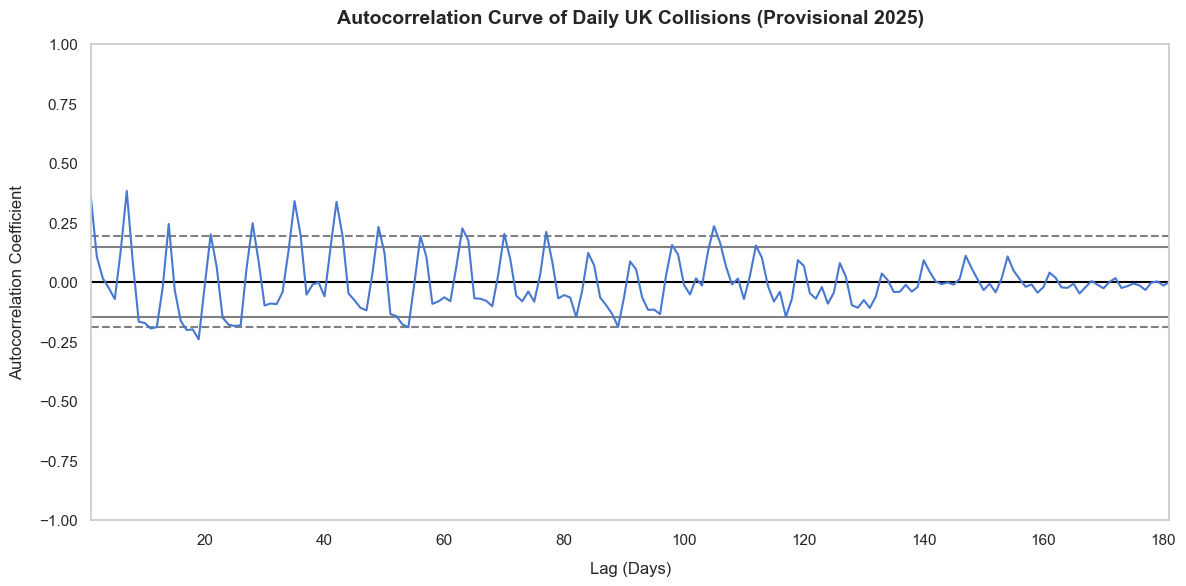

In [15]:
plt.figure(figsize=(12, 6))

pd.plotting.autocorrelation_plot(daily_trend['collision_count'])

plt.title("Autocorrelation Curve of Daily UK Collisions (Provisional 2025)", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Lag (Days)", fontsize=12, labelpad=10)
plt.ylabel("Autocorrelation Coefficient", fontsize=12, labelpad=10)
plt.tight_layout()

plt.savefig(os.path.join(workspace_dir, "plot7_autocorrelation.png"), dpi=300)
plt.show()


## 6. Conclusions and Policy Implications
* **Statistical Insights:** The Logistic Regression results reveal that speed limits of 60 mph and 70 mph have significantly higher Odds Ratios of fatal/serious injury compared to urban 30 mph limits.
* **Environmental Impact:** Adverse weather and wet/damp road surface conditions increase the likelihood of accidents, though the severity of crashes is strongly driven by speed and rural settings.
* **Vulnerable Demographics:** The violin plots show that pedestrians and passengers suffer severe injuries at younger age distributions compared to drivers.
* **Policy Recommendation:** High-speed rural road networks and vulnerable pedestrian pathways in urban areas require targeted safety interventions.

